In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
hdir = "~/Projects/Python/learning/"

In [6]:
bnames1880 = pd.read_csv(hdir+"data/names/yob1880.txt", 
                         names=["name", "sex", "births"])

In [7]:
bnames1880

,name,sex,births
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746
...,...,...,...
1995,Woodie,M,5
1996,Worthy,M,5
1997,Wright,M,5
1998,York,M,5


In [11]:
# total births in 1880 with available > 5 names
bnames1880.groupby("sex")["births"].sum()

sex
F     90994
M    110490
Name: births, dtype: int64

### Join all the names together in one dataframe (pd.concat)

In [14]:
bnameslist = []
for year in range(1880, 2025):
    path = f"data/names/yob{year}.txt"
    frame = pd.read_csv(hdir+path, names=["name", "sex", "births"])

    # year column
    frame["year"] = year
    bnameslist.append(frame)

bnames = pd.concat(bnameslist, ignore_index=True)

In [16]:
bnames

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
2149472,Zylyn,M,5,2024
2149473,Zymiere,M,5,2024
2149474,Zypher,M,5,2024
2149475,Zyre,M,5,2024


### Aggregating tasks

In [18]:
total_births = bnames.pivot_table("births", index="year", columns="sex", aggfunc="sum")

In [19]:
total_births

sex,F,M
year,,
1880,90994,110490
1881,91953,100735
1882,107847,113686
1883,112321,104625
1884,129019,114442
...,...,...
2020,1615512,1725065
2021,1639712,1748237
2022,1638762,1744373


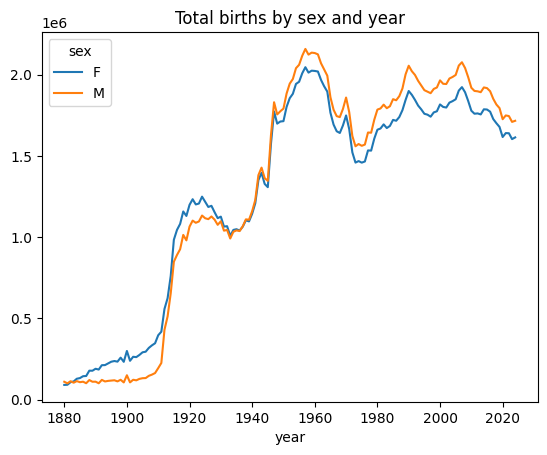

In [21]:
total_births.plot(title="Total births by sex and year");

### What's the proportion of babies with a given name

In [33]:
def add_prop(group):
    group["prop"] = group["births"] / group["births"].sum()
    return group
bnames = pd.concat(bnameslist, ignore_index=True)
bnames = bnames.groupby(["year", "sex"], group_keys=False).apply(add_prop, include_groups=True)
bnames

/tmp/ipykernel_85074/1164406166.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bnames = bnames.groupby(["year", "sex"], group_keys=False).apply(add_prop, include_groups=True)


,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077642
1,Anna,F,2604,1880,0.028617
2,Emma,F,2003,1880,0.022012
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
2149472,Zylyn,M,5,2024,0.000003
2149473,Zymiere,M,5,2024,0.000003
2149474,Zypher,M,5,2024,0.000003
2149475,Zyre,M,5,2024,0.000003


In [28]:
bnames.groupby?


Signature:
bnames.groupby(
    by=None,
    axis: 'Axis | lib.NoDefault' = <no_default>,
    level: 'IndexLabel | None' = None,
    as_index: 'bool' = True,
    sort: 'bool' = True,
    group_keys: 'bool' = True,
    observed: 'bool | lib.NoDefault' = <no_default>,
    dropna: 'bool' = True,
) -> 'DataFrameGroupBy'
Docstring:
Group DataFrame using a mapper or by a Series of columns.

A groupby operation involves some combination of splitting the
object, applying a function, and combining the results. This can be
used to group large amounts of data and compute operations on these
groups.

Parameters
----------
by : mapping, function, label, pd.Grouper or list of such
    Used to determine the groups for the groupby.
    If ``by`` is a function, it's called on each value of the object's
    index. If a dict or Series is passed, the Series or dict VALUES
    will be used to determine the groups (the Series' values are first
    aligned; see ``.align()`` method). If a list or ndarray of le

In [36]:
# double checking that the proportion is alright
bnames.groupby(["year", "sex"])["prop"].sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2022  M      1.0
2023  F      1.0
      M      1.0
2024  F      1.0
      M      1.0
Name: prop, Length: 290, dtype: float64

yuup! each one sums to one!

### Analysis time

In [53]:
def get_top1000(group):
    return group.sort_values("births", ascending=False)[:1000]



In [54]:
groupednames = bnames.groupby(["year", "sex"])

In [62]:
top1000 = groupednames.apply(get_top1000).reset_index(drop=True)

/tmp/ipykernel_85074/3968057005.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1000 = groupednames.apply(get_top1000).reset_index(drop=True)


In [63]:
top1000.head()d

,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077642
1,Anna,F,2604,1880,0.028617
2,Emma,F,2003,1880,0.022012
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188


### Analysing name trends

In [64]:
boys = top1000[top1000["sex"] == "M"]

In [66]:
girls = top1000[top1000["sex"] == "F"]

In [67]:
total_births = top1000.pivot_table("births", index="year", columns="name", aggfunc="sum")
total_births

name,Aaden,Aadhya,Aaliyah,Aanya,Aarav,Aarna,Aaron,Aarush,Aarya,Aayan,...,Zona,Zora,Zoya,Zula,Zuri,Zyair,Zyaire,Zyla,Zymir,Zyon
year,,,,,,,,,,,,,,,,,,,,,
1880,NaN,NaN,NaN,NaN,NaN,NaN,102.0,NaN,NaN,NaN,...,8.0,28.0,NaN,27.0,NaN,NaN,NaN,NaN,NaN,NaN
1881,NaN,NaN,NaN,NaN,NaN,NaN,94.0,NaN,NaN,NaN,...,9.0,21.0,NaN,27.0,NaN,NaN,NaN,NaN,NaN,NaN
1882,NaN,NaN,NaN,NaN,NaN,NaN,85.0,NaN,NaN,NaN,...,17.0,32.0,NaN,21.0,NaN,NaN,NaN,NaN,NaN,NaN
1883,NaN,NaN,NaN,NaN,NaN,NaN,105.0,NaN,NaN,NaN,...,11.0,35.0,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN
1884,NaN,NaN,NaN,NaN,NaN,NaN,97.0,NaN,NaN,NaN,...,8.0,58.0,NaN,27.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,NaN,NaN,3578.0,NaN,419.0,NaN,5098.0,NaN,256.0,NaN,...,NaN,308.0,282.0,NaN,1268.0,226.0,672.0,NaN,NaN,NaN
2021,NaN,NaN,3613.0,NaN,431.0,268.0,4851.0,NaN,NaN,NaN,...,NaN,338.0,267.0,NaN,1440.0,324.0,835.0,NaN,NaN,242.0
2022,NaN,268.0,3284.0,NaN,406.0,NaN,4524.0,NaN,NaN,NaN,...,NaN,332.0,358.0,NaN,1520.0,354.0,871.0,NaN,NaN,277.0


In [69]:
# 7386 unique names across 145 years
total_births.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 1880 to 2024
Columns: 7386 entries, Aaden to Zyon
dtypes: float64(7386)
memory usage: 8.2 MB


In [70]:
total_births.columns

Index(['Aaden', 'Aadhya', 'Aaliyah', 'Aanya', 'Aarav', 'Aarna', 'Aaron',
       'Aarush', 'Aarya', 'Aayan',
       ...
       'Zona', 'Zora', 'Zoya', 'Zula', 'Zuri', 'Zyair', 'Zyaire', 'Zyla',
       'Zymir', 'Zyon'],
      dtype='object', name='name', length=7386)

In [71]:
for name in total_births.columns:
    print(name)

Aaden
Aadhya
Aaliyah
Aanya
Aarav
Aarna
Aaron
Aarush
Aarya
Aayan
Ab
Abagail
Abb
Abbey
Abbie
Abbigail
Abbott
Abby
Abdiel
Abdul
Abdullah
Abe
Abel
Abelardo
Abie
Abigail
Abigale
Abigayle
Abner
Abraham
Abram
Abrielle
Abril
Ace
Acey
Achilles
Acie
Acy
Ada
Adah
Adalberto
Adalee
Adaline
Adalyn
Adalynn
Adam
Adamaris
Adams
Adan
Add
Adda
Addie
Addilyn
Addilynn
Addison
Addisyn
Addyson
Adel
Adela
Adelaide
Adelard
Adelbert
Adele
Adelia
Adelina
Adeline
Adell
Adella
Adelle
Adelyn
Adelynn
Aden
Adhara
Adilene
Adilynn
Adin
Adina
Adison
Aditya
Adlai
Adler
Adley
Adline
Admiral
Adolf
Adolfo
Adolph
Adolphus
Adonis
Adrain
Adria
Adrian
Adriana
Adriane
Adrianna
Adrianne
Adriel
Adrien
Adriene
Adrienne
Adron
Adyson
Aedan
Affie
Afton
Agatha
Aggie
Agnes
Agness
Agusta
Agustin
Agustus
Ah
Ahmad
Ahmed
Ahmir
Aida
Aidan
Aiden
Aidyn
Aila
Ailani
Ailany
Aileen
Ailene
Aili
Aime
Aimee
Ainara
Ainhoa
Ainsley
Aisha
Aislinn
Aitana
Aiyana
Aiyanna
Aja
Akeelah
Akeem
Akira
Al
Alaia
Alain
Alaina
Alaiya
Alan
Alana
Alani
Alanna
Alannah
Al

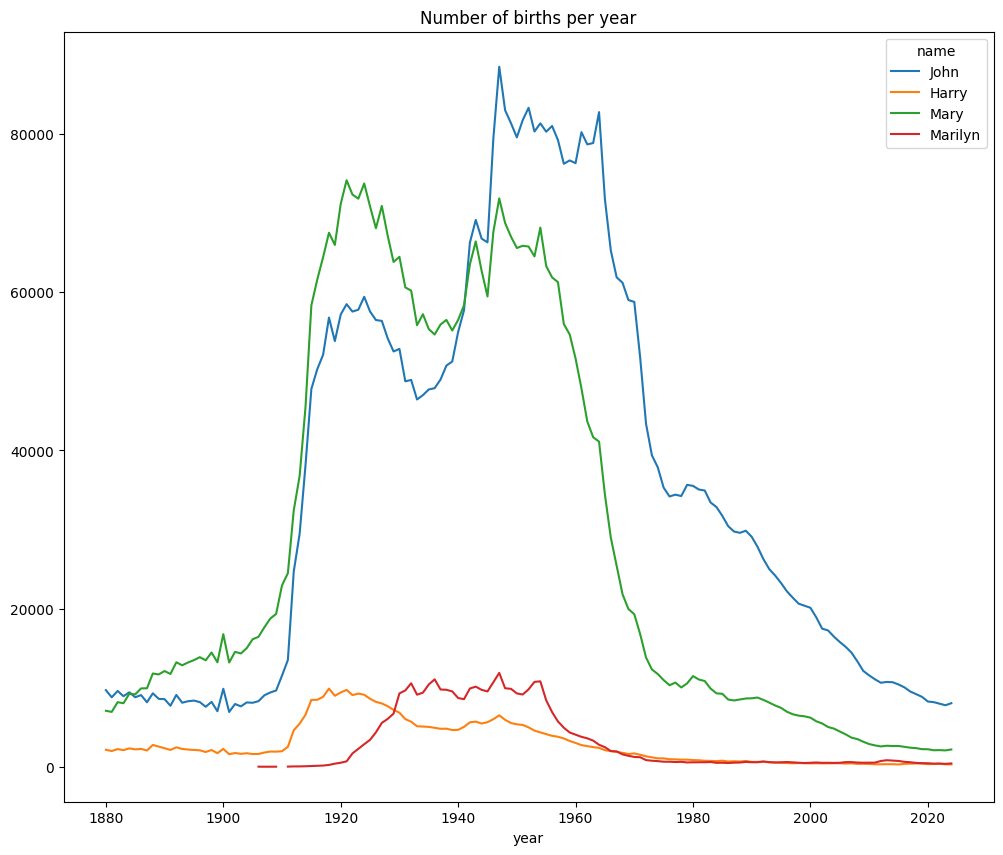

In [159]:
subset = total_births[["John", "Harry", "Mary", "Marilyn"]]
subset.plot(subplots=False, figsize=(12, 10), title="Number of births per year")
fig.tight_layout()


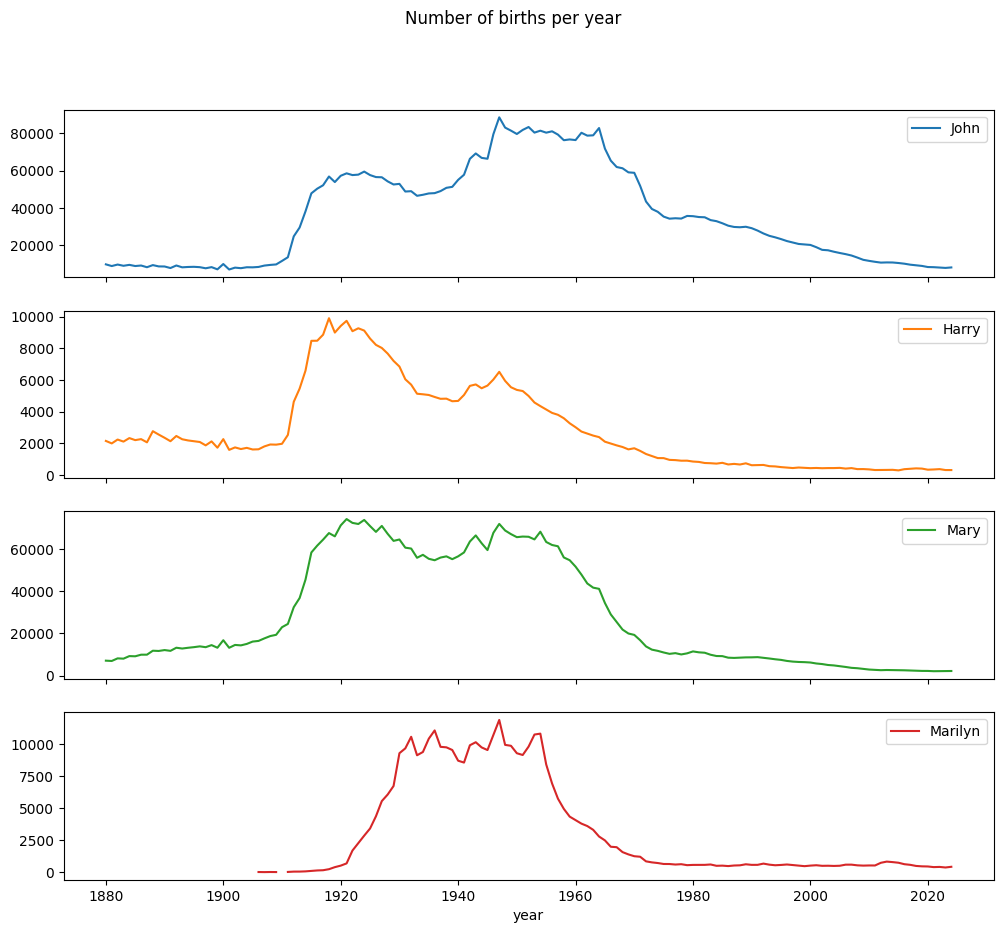

In [75]:
subset.plot(subplots=True, figsize=(12, 10), title="Number of births per year");

### Measuring the increase in naming diversity

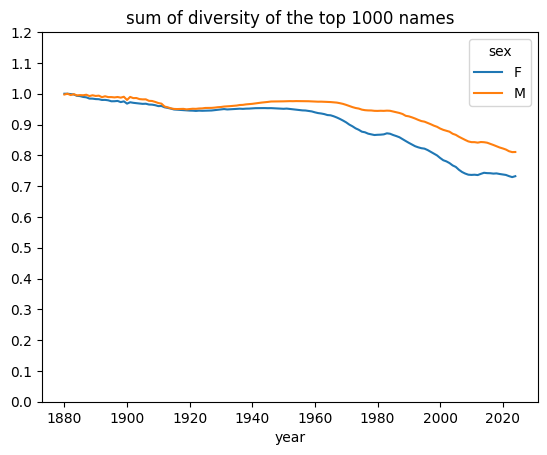

In [80]:
# Are the names really dropping or is it due to parents choosing other non-popular names?

table = top1000.pivot_table("prop", index="year", columns="sex", aggfunc="sum")
table.plot(title="sum of diversity of the top 1000 names",
           yticks=np.linspace(0,1.2,13));

And the divergence and decrease does indeed confirm that the popular names are declining.

### What are the popular names?


In [83]:
# Using 2012 for example

boydf = boys[boys["year"] == 2020]
boydf

,name,sex,births,year,prop
280876,Liam,M,19858,2020,0.011511
280877,Noah,M,18451,2020,0.010696
280878,Oliver,M,14275,2020,0.008275
280879,Elijah,M,13224,2020,0.007666
280880,William,M,12673,2020,0.007346
...,...,...,...,...,...
281871,Harris,M,214,2020,0.000124
281872,Jericho,M,214,2020,0.000124
281873,Rogelio,M,213,2020,0.000123
281874,Billy,M,212,2020,0.000123


### How many most popular names will it take to get 50%
1. Sort prop in descending order
2. Take cumulative sum of prop
3. Use searchsorted with position at 0.5



In [84]:
prop_cumsum = boydf["prop"].sort_values(ascending=False).cumsum()
prop_cumsum.head()

280876    0.011511
280877    0.022207
280878    0.030482
280879    0.038148
280880    0.045495
Name: prop, dtype: float64

In [85]:
prop_cumsum.searchsorted(0.5)

np.int64(162)

Therefore 162 + 1 = 163 is how many names it takes to get to 50% in 2020. (+1 because of 0-indexing)

What about in 1990?

In [87]:
boy1990 = boys[boys["year"] == 1990]
boy1990["prop"].sort_values(ascending=False).cumsum().searchsorted(0.5)

np.int64(44)

In [93]:
boy1990.sort_values("prop", ascending=False).prop.cumsum().searchsorted(0.5)

np.int64(44)

In 1990, it would take `(44+1)` to get to 50%

Let's expand this to the year-sex combination to see how it results for both boys and girls across the years.

In [96]:
def get_quantile_count(group, q=0.5):
    group = group.sort_values("prop", ascending=False)
    return group.prop.cumsum().searchsorted(q) + 1

# Group the top 1000 names by year and sex
diversity = top1000.groupby(["year", "sex"]).apply(get_quantile_count, include_groups=False)
diversity

year  sex
1880  F       38
      M       14
1881  F       38
      M       14
1882  F       38
            ... 
2022  M      173
2023  F      288
      M      178
2024  F      283
      M      178
Length: 290, dtype: int64

In [98]:
diversity = diversity.unstack()

<Axes: title={'center': 'Number of popular names in top 50%'}, xlabel='year'>

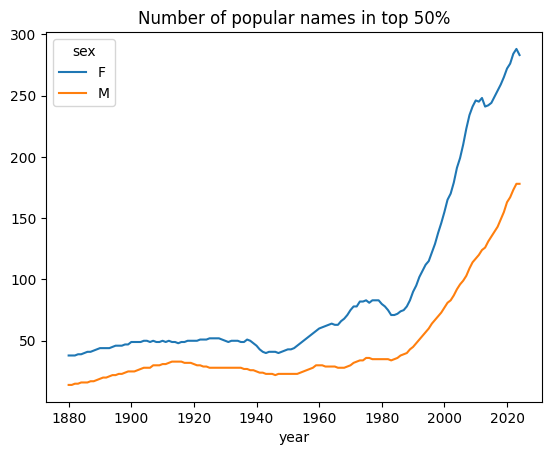

In [99]:
diversity.plot(title="Number of popular names in top 50%")

### The last name revolution

In [102]:
def get_last_letter(x):
    return x[-1]



In [106]:
last_letters = bnames["name"].map(get_last_letter) # can also use apply
last_letters.name = "last_letter"#["name"]

In [108]:
bnames.columns

Index(['name', 'sex', 'births', 'year', 'prop'], dtype='object')

In [132]:
table = bnames.pivot_table("births", index=last_letters, columns=["sex", "year"], aggfunc="sum")

In [133]:
table

sex                F                                                        \
year            1880     1881     1882     1883     1884     1885     1886   
last_letter                                                                  
a            31446.0  31581.0  36536.0  38330.0  43680.0  45408.0  49100.0   
b                NaN      NaN      NaN      NaN      NaN      NaN      NaN   
c                NaN      NaN      5.0      5.0      NaN      NaN      NaN   
d              609.0    607.0    734.0    810.0    916.0    862.0   1007.0   
e            33381.0  34080.0  40399.0  41914.0  48089.0  49616.0  53883.0   
f                NaN      NaN      NaN      NaN      NaN      NaN      NaN   
g                7.0      5.0     12.0      8.0     24.0     11.0     18.0   
h             4863.0   4783.0   5566.0   5701.0   6602.0   6623.0   7146.0   
i               61.0     78.0     81.0     76.0     84.0     92.0     85.0   
j                NaN      NaN      NaN      NaN      NaN      NaN      NaN   
k               13.0     15.0     11.0     17.0     21.0     18.0     27.0   
l             2541.0   2910.0   3527.0   3848.0   4807.0   5144.0   5721.0   
m               58.0     57.0     81.0     86.0     79.0     75.0    103.0   
n             3008.0   2959.0   3575.0   3836.0   4507.0   4735.0   5242.0   
o               30.0     49.0     35.0     47.0     74.0     84.0     93.0   
p                NaN      NaN      NaN      NaN      NaN      NaN      NaN   
q                NaN      NaN      NaN      NaN      NaN      NaN      NaN   
r              481.0    417.0    590.0    640.0    718.0    799.0    917.0   
s             1391.0   1316.0   1637.0   1794.0   2038.0   2127.0   2524.0   
t             2152.0   2165.0   2399.0   2554.0   2824.0   2889.0   3017.0   
u              380.0    427.0    410.0    444.0    490.0    495.0    511.0   
v                NaN      NaN      NaN      NaN      NaN      NaN      NaN   
w                NaN      5.0      NaN      NaN      NaN      NaN      5.0   
x                NaN      NaN      NaN      7.0      NaN      NaN      NaN   
y            10467.0  10404.0  12143.0  12063.0  13918.0  13927.0  14932.0   
z              106.0     95.0    106.0    141.0    148.0    150.0    202.0   

sex                                     ...         M                      \
year            1887     1888     1889  ...      2015      2016      2017   
last_letter                             ...                                 
a            48941.0  59440.0  58631.0  ...   29090.0   29809.0   30384.0   
b                NaN      NaN      NaN  ...   29669.0   27046.0   24636.0   
c                NaN      NaN      NaN  ...   23178.0   22103.0   20624.0   
d             1027.0   1298.0   1374.0  ...   43868.0   43100.0   42206.0   
e            54353.0  66748.0  66662.0  ...  128856.0  126356.0  122294.0   
f                NaN      NaN      NaN  ...    2829.0    2846.0    2844.0   
g               25.0     44.0     28.0  ...    4976.0    5320.0    5326.0   
h             7141.0   8630.0   8825.0  ...  102837.0  102658.0   99881.0   
i              105.0    141.0    134.0  ...   49137.0   49289.0   50215.0   
j                NaN      NaN      NaN  ...    1455.0    1432.0    1485.0   
k               19.0     21.0     22.0  ...   35446.0   36096.0   36858.0   
l             6174.0   7900.0   8395.0  ...  128040.0  126469.0  121656.0   
m               90.0    123.0    137.0  ...   59220.0   59602.0   59274.0   
n             5512.0   6832.0   7103.0  ...  663329.0  649004.0  625132.0   
o               97.0    134.0    142.0  ...   86685.0   91296.0   93184.0   
p                NaN      NaN      NaN  ...    2384.0    2357.0    2500.0   
q                NaN      NaN      NaN  ...     351.0     406.0     411.0   
r              910.0   1207.0   1214.0  ...  181371.0  178187.0  173205.0   
s             2803.0   3581.0   3569.0  ...  130307.0  133540.0  133176.0   
t             3140.0   3816.0   3784.0  ...

In [134]:
# Take three equally-spaced years that are also representative : 1910, 1960, 2010

subtable = table.reindex(columns=[1910, 1960, 2010], level="year")

In [135]:
subtable


sex                 F                            M                    
year             1910      1960      2010     1910      1960      2010
last_letter                                                           
a            108399.0  691254.0  677566.0    977.0    5216.0   28906.0
b                 NaN     694.0     455.0    411.0    3913.0   39320.0
c                 5.0      49.0     958.0    482.0   15456.0   23378.0
d              6751.0    3732.0    2645.0  22111.0  262105.0   44876.0
e            133599.0  435000.0  317138.0  28665.0  178731.0  130395.0
f                 NaN      20.0      97.0    152.0    9233.0    2313.0
g                57.0     316.0     669.0    439.0   20226.0    2699.0
h             20432.0   73238.0  135114.0   8849.0   80826.0   99449.0
i               605.0   80808.0   56338.0    164.0    1298.0   43494.0
j                 NaN       NaN     165.0      NaN       NaN    1484.0
k                48.0     314.0     633.0   7104.0  105245.0   35549.0
l             17124.0   68482.0   46900.0  12628.0  223609.0  135159.0
m               476.0   17412.0    4624.0  11273.0   72118.0   47396.0
n             31418.0  264211.0  248910.0  27847.0  325162.0  695225.0
o               663.0    4930.0    2217.0   3314.0   27358.0   81630.0
p                 7.0      47.0      35.0    616.0   12098.0    2433.0
q                 NaN       NaN      53.0      NaN       NaN     345.0
r              5311.0   13679.0   32071.0  12521.0   66194.0  167654.0
s             15478.0   25801.0   23707.0  25402.0  218935.0  125004.0
t             10877.0   30724.0   13929.0  14155.0  139949.0   43848.0
u               271.0    1162.0     739.0     24.0     121.0    2355.0
v                 NaN     122.0     208.0     22.0      77.0    2782.0
w                 8.0      63.0    2116.0   1228.0   16425.0   31044.0
x                 6.0      74.0    1299.0    770.0    3947.0   16493.0
y             44002.0  308438.0  207497.0  15021.0  343282.0  111671.0
z               966.0    1330.0    1244.0     33.0     391.0    3510.0

In [136]:
# Normalise using the sum of each year and the value of each year 
subtable.sum()

sex  year
F    1910     396503.0
     1960    2021900.0
     2010    1777327.0
M    1910     194208.0
     1960    2131915.0
     2010    1918412.0
dtype: float64

In [137]:
letter_prop = subtable / subtable.sum()

In [129]:
15021.0/194208

0.07734490855165596

In [138]:
letter_prop.tail()

sex                 F                             M                    
year             1910      1960      2010      1910      1960      2010
last_letter                                                            
v                 NaN  0.000060  0.000117  0.000113  0.000036  0.001450
w            0.000020  0.000031  0.001191  0.006323  0.007704  0.016182
x            0.000015  0.000037  0.000731  0.003965  0.001851  0.008597
y            0.110975  0.152549  0.116747  0.077345  0.161020  0.058210
z            0.002436  0.000658  0.000700  0.000170  0.000183  0.001830

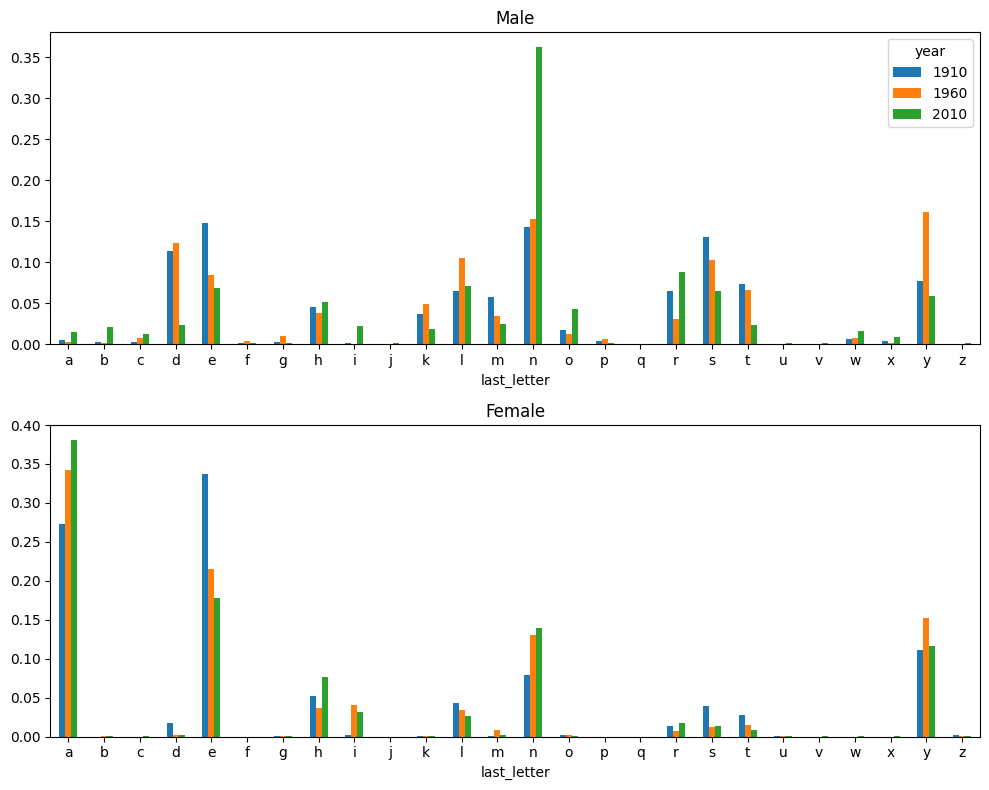

In [142]:
# Time for some plotting

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
letter_prop["M"].plot(kind="bar", rot=0, ax=axes[0], title="Male")
letter_prop["F"].plot(kind="bar", rot=0, ax=axes[1], title="Female", legend=False)
fig.tight_layout();

In [143]:
# Normalise the entire table for a broader analysis
letter_prop_all = table / table.sum()
dny_ts = letter_prop_all.loc[["d", "n", "y"], "M"]
dny_ts

year,1880,1881,1882,1883,1884,1885,1886,1887,1888,1889,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
last_letter,,,,,,,,,,,,,,,,,,,,,
d,0.083057,0.083238,0.085332,0.084053,0.086122,0.085474,0.087649,0.089073,0.087711,0.091915,...,0.022893,0.022718,0.022810,0.023094,0.022796,0.022619,0.022612,0.022567,0.022369,0.022310
n,0.153217,0.153214,0.149561,0.151656,0.149927,0.146346,0.149653,0.148840,0.151284,0.151990,...,0.346159,0.342083,0.337851,0.333488,0.323695,0.314531,0.306146,0.296826,0.291732,0.284230
y,0.075763,0.077461,0.077538,0.079149,0.080408,0.081884,0.081682,0.082871,0.084922,0.086336,...,0.053437,0.051419,0.049952,0.048832,0.048085,0.047835,0.047667,0.047515,0.047065,0.047191


In [145]:
dny_ts = dny_ts.T

<Axes: title={'center': "Proportion of boys' names ending in `d, n, y`"}, xlabel='year'>

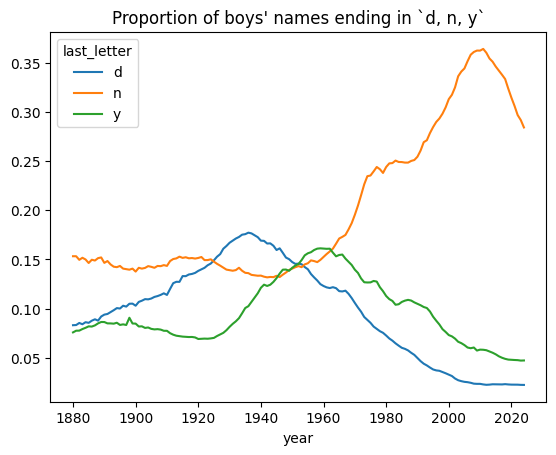

In [152]:
dny_ts.plot(title="Proportion of boys' names ending in `d, n, y`")
#fig.tight_layout;

In [160]:
top1000.columns

Index(['name', 'sex', 'births', 'year', 'prop'], dtype='object')

In [162]:
### Names flipping sex
all_names = pd.Series(top1000["name"].unique())

lesley_like = all_names[all_names.str.contains("Lesl")]
lesley_like

654     Leslie
2306    Lesley
4257    Leslee
4725     Lesli
6095     Lesly
dtype: object

In [166]:
filtered_lesl = top1000[top1000["name"].isin(lesley_like)]

In [171]:
filtered_lesl

,name,sex,births,year,prop
654,Leslie,F,8,1880,0.000088
1108,Leslie,M,79,1880,0.000715
2464,Leslie,F,11,1881,0.000120
3014,Leslie,M,92,1881,0.000913
4534,Leslie,F,9,1882,0.000083
...,...,...,...,...,...
280471,Leslie,F,488,2020,0.000302
282499,Leslie,F,477,2021,0.000291
284528,Leslie,F,453,2022,0.000276
286545,Leslie,F,440,2023,0.000275


In [170]:
filtered_lesl.groupby("name")["births"].sum()

name
Leslee      1083
Lesley     34986
Lesli        929
Leslie    381122
Lesly      11434
Name: births, dtype: int64

In [172]:
filtered_lesl.pivot_table("births", index="name", columns="sex", aggfunc="sum")

sex,F,M
name,,
Leslee,1083.0,NaN
Lesley,32061.0,2925.0
Lesli,929.0,NaN
Leslie,270029.0,111093.0
Lesly,11434.0,NaN


In [174]:
ftable = filtered_lesl.pivot_table("births", index="year", columns="sex", aggfunc="sum")

In [176]:
ftable

sex,F,M
year,,
1880,8.0,79.0
1881,11.0,92.0
1882,9.0,128.0
1883,7.0,125.0
1884,15.0,125.0
...,...,...
2020,488.0,NaN
2021,477.0,NaN
2022,453.0,NaN


In [191]:
# normalise by year (each div by the sum of f and m)
ftableplt = ftable.div(ftable.sum(axis="columns"), axis="index")

<Axes: title={'center': 'Leslie-like names for boys and girls over time'}, xlabel='year'>

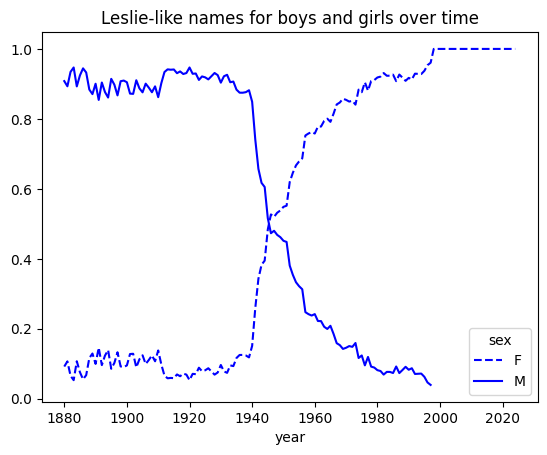

In [193]:
ftableplt.plot(title="Leslie-like names for boys and girls over time",
               style={"M": "b-", "F":"b--"})